# CLT Convergence Test: Does the Gaussian Approximation Improve with p?

The `interaction_diagnostics` notebook found that the analytic `E[f^2]` (arc-cosine kernel)
overestimates the empirical value by 80-225% at p=30 on binomial genotypes. The hypothesis
is that this is a **small-p artifact**: projections `w'x` (sums of p correlated binomial
variables) become increasingly Gaussian as p grows via the CLT.

This notebook tests that claim by sweeping **p = 30, 100, 300, 1000, 3000** and measuring:

1. **E[f^2] approximation error** — analytic vs empirical, as a function of p
2. **Projection normality** — QQ plots, Anderson-Darling test, excess kurtosis
3. **Full loss accuracy** — analytic interaction loss vs empirical MSE
4. **Interaction NN gap to Oracle** — does the R^2 gap shrink at larger p?

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats as sp_stats

from ssnn.simulation import (
    generate_maf_spectrum,
    generate_binomial_genotypes,
    generate_effect_sizes,
    compute_summary_stats_from_genotypes,
    train_oracle_nn,
    _calibrate_gamma,
)
from ssnn.optimizer import train
from ssnn.interaction_optimizer import train_interaction
from ssnn.interaction_risk import compute_interaction_loss
from ssnn.gaussian_integrals import activation_cross_moment, stein_cross_moment
from ssnn.interaction_integrals import interaction_cross_moment
from ssnn.utils import (
    generate_ld_matrix,
    nn_predict,
    nn_prediction_r2,
    prediction_r2,
)

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    "figure.figsize": (12, 6),
    "font.size": 12,
    "axes.titlesize": 14,
    "axes.labelsize": 12,
})

In [2]:
P_VALUES = [30, 100, 300, 1000, 3000]
M = 5
HERITABILITY = 0.5
SPARSITY = 0.3
LD_DECAY = 0.5
MAF_SPECTRUM = "mixed"
ACTIVATION = "relu"
NONLINEAR_FRAC = 0.50
SEED = 42


def get_n_train(p):
    return max(5000, 10 * p)


def get_n_test(p):
    return max(2000, 4 * p)


def generate_replicate(p, seed):
    """Generate one full replicate for a given p."""
    rng = np.random.default_rng(seed)
    n_train = get_n_train(p)
    n_test = get_n_test(p)

    maf = generate_maf_spectrum(p, MAF_SPECTRUM, rng)
    Sigma = generate_ld_matrix(p, decay=LD_DECAY)
    beta_star, sigma_eps = generate_effect_sizes(p, Sigma, HERITABILITY, SPARSITY, rng)

    X_train_raw = generate_binomial_genotypes(n_train, maf, Sigma, rng)
    X_test_raw = generate_binomial_genotypes(n_test, maf, Sigma, rng)

    train_means = X_train_raw.mean(axis=0)
    X_train = X_train_raw - train_means
    X_test = X_test_raw - train_means

    w_star = rng.standard_normal(p) * 0.3
    gamma_coeff = _calibrate_gamma(X_train, beta_star, w_star, NONLINEAR_FRAC)

    var_linear = np.var(X_train @ beta_star)
    var_nonlinear = np.var(gamma_coeff * np.maximum(0.0, X_train @ w_star))
    total_genetic_var = var_linear + var_nonlinear
    sigma_eps = float(np.sqrt(total_genetic_var * (1 - HERITABILITY) / HERITABILITY))

    y_train = (
        X_train @ beta_star
        + gamma_coeff * np.maximum(0.0, X_train @ w_star)
        + rng.normal(0, sigma_eps, n_train)
    )
    y_test = (
        X_test @ beta_star
        + gamma_coeff * np.maximum(0.0, X_test @ w_star)
        + rng.normal(0, sigma_eps, n_test)
    )

    sumstats = compute_summary_stats_from_genotypes(X_train_raw, y_train, Sigma)

    return {
        "rng": rng,
        "p": p,
        "n_train": n_train,
        "n_test": n_test,
        "maf": maf,
        "Sigma": Sigma,
        "beta_star": beta_star,
        "sigma_eps": sigma_eps,
        "w_star": w_star,
        "gamma_coeff": gamma_coeff,
        "X_train": X_train,
        "X_test": X_test,
        "y_train": y_train,
        "y_test": y_test,
        "Sigma_beta_hat": sumstats["Sigma_beta_hat"],
        "E_y2_hat": sumstats["E_y2_hat"],
        "Gamma_hat": sumstats["Gamma_hat"],
    }

## Analysis 1: E[f^2] Approximation Error vs p

For each p, we train a Gaussian NN to get realistic weight scales, then compare the
arc-cosine kernel formula `E[f^2]` against the empirical value computed from the
binomial genotype data. If the CLT hypothesis is correct, the relative error should
shrink toward zero as p grows.

In [3]:
ef2_results = []

for p in P_VALUES:
    print(f"p={p:>5d} ...", end=" ", flush=True)
    data = generate_replicate(p, SEED)

    gauss = train(
        data["Sigma"], data["Sigma_beta_hat"], data["E_y2_hat"],
        m=M, activation=ACTIVATION, lr=0.01, max_iters=3000,
        init_scale=0.01, rng=np.random.default_rng(100),
    )

    a, W = gauss.a, gauss.W
    Sigma = data["Sigma"]

    ef2_analytic = sum(
        a[k] * a[l] * activation_cross_moment(Sigma, W[k], W[l], ACTIVATION)
        for k in range(M) for l in range(M)
    )

    f_train = nn_predict(data["X_train"], a, W, ACTIVATION)
    ef2_empirical = float(np.mean(f_train ** 2))

    rel_err = abs(ef2_analytic - ef2_empirical) / (abs(ef2_empirical) + 1e-30)

    ef2_results.append({
        "p": p,
        "ef2_analytic": ef2_analytic,
        "ef2_empirical": ef2_empirical,
        "rel_error": rel_err,
        "norm_a": float(np.linalg.norm(a)),
        "norm_W": float(np.linalg.norm(W)),
    })
    print(f"E[f^2] analytic={ef2_analytic:.4f}, empirical={ef2_empirical:.4f}, "
          f"rel_err={rel_err:.1%}")

print("\n--- Summary ---")
print(f"{'p':>6s} {'E[f^2] analytic':>16s} {'E[f^2] empirical':>17s} {'Rel Error':>12s}")
print("-" * 55)
for r in ef2_results:
    print(f"{r['p']:6d} {r['ef2_analytic']:16.6f} {r['ef2_empirical']:17.6f} {r['rel_error']:11.1%}")

p=   30 ... 

E[f^2] analytic=1.2911, empirical=0.6528, rel_err=97.8%
p=  100 ... 

E[f^2] analytic=5.7316, empirical=3.0179, rel_err=89.9%
p=  300 ... 

E[f^2] analytic=19.0587, empirical=9.8093, rel_err=94.3%
p= 1000 ... 

E[f^2] analytic=46.6848, empirical=26.2716, rel_err=77.7%
p= 3000 ... 

E[f^2] analytic=178.4893, empirical=101.7310, rel_err=75.5%

--- Summary ---
     p  E[f^2] analytic  E[f^2] empirical    Rel Error
-------------------------------------------------------
    30         1.291088          0.652755       97.8%
   100         5.731591          3.017885       89.9%
   300        19.058708          9.809290       94.3%
  1000        46.684814         26.271632       77.7%
  3000       178.489259        101.730985       75.5%


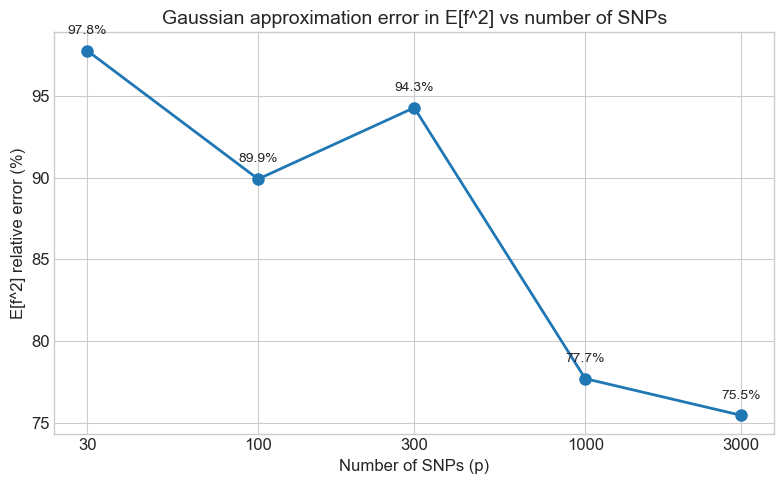

In [4]:
fig, ax = plt.subplots(figsize=(8, 5))
ps = [r["p"] for r in ef2_results]
errs = [r["rel_error"] * 100 for r in ef2_results]
ax.plot(ps, errs, 'o-', markersize=8, linewidth=2)
ax.set_xscale("log")
ax.set_xlabel("Number of SNPs (p)")
ax.set_ylabel("E[f^2] relative error (%)")
ax.set_title("Gaussian approximation error in E[f^2] vs number of SNPs")
ax.set_xticks(ps)
ax.set_xticklabels([str(p) for p in ps])
for p_val, err in zip(ps, errs):
    ax.annotate(f"{err:.1f}%", (p_val, err), textcoords="offset points",
                xytext=(0, 12), ha="center", fontsize=10)
plt.tight_layout()
plt.show()

## Analysis 2: Projection Normality Test

For each p, we compute the projection `w'x` using a trained weight vector and test
whether the distribution is close to Gaussian. We use:
- QQ plots against the normal distribution
- Anderson-Darling test (p-value)
- Excess kurtosis (0 for a perfect Gaussian)

If the CLT is working, excess kurtosis should shrink toward 0 and the QQ plots
should become increasingly linear.

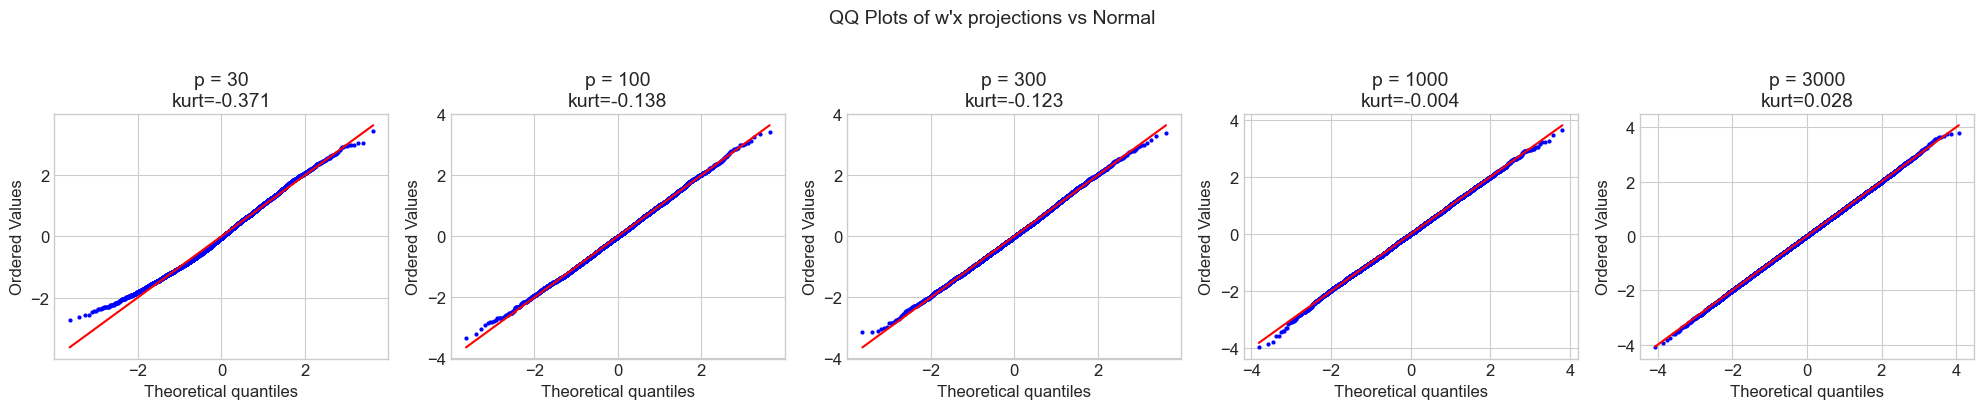

     p   AD Statistic   Excess Kurtosis   Skewness
--------------------------------------------------
    30         7.7080           -0.3712     0.2158
   100         0.6734           -0.1378     0.0649
   300         0.8595           -0.1234     0.0749
  1000         0.5183           -0.0043    -0.0032
  3000         0.1169            0.0281    -0.0027


In [5]:
normality_results = []

fig, axes = plt.subplots(1, len(P_VALUES), figsize=(4 * len(P_VALUES), 4))

for idx, p in enumerate(P_VALUES):
    data = generate_replicate(p, SEED)

    gauss = train(
        data["Sigma"], data["Sigma_beta_hat"], data["E_y2_hat"],
        m=M, activation=ACTIVATION, lr=0.01, max_iters=3000,
        init_scale=0.01, rng=np.random.default_rng(100),
    )

    w = gauss.W[0]
    projection = data["X_train"] @ w
    proj_std = (projection - projection.mean()) / (projection.std() + 1e-30)

    ad_stat, ad_crit, ad_sig = sp_stats.anderson(proj_std, dist='norm')
    excess_kurt = float(sp_stats.kurtosis(proj_std, fisher=True))
    skewness = float(sp_stats.skew(proj_std))

    normality_results.append({
        "p": p,
        "ad_statistic": ad_stat,
        "excess_kurtosis": excess_kurt,
        "skewness": skewness,
    })

    ax = axes[idx]
    sp_stats.probplot(proj_std, dist="norm", plot=ax)
    ax.set_title(f"p = {p}\nkurt={excess_kurt:.3f}")
    ax.get_lines()[0].set_markersize(2)

plt.suptitle("QQ Plots of w'x projections vs Normal", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

print(f"{'p':>6s} {'AD Statistic':>14s} {'Excess Kurtosis':>17s} {'Skewness':>10s}")
print("-" * 50)
for r in normality_results:
    print(f"{r['p']:6d} {r['ad_statistic']:14.4f} {r['excess_kurtosis']:17.4f} {r['skewness']:10.4f}")

## Analysis 3: Full Loss Accuracy vs p

We compare the full analytic interaction loss to the empirical train MSE at each p.
This includes both the `E[y*f]` and `E[f^2]` terms, showing whether the overall
loss function becomes a reliable proxy for MSE as p grows.

We also break down the error into the two components to show which one dominates.

In [6]:
loss_results = []

for p in P_VALUES:
    print(f"p={p:>5d} ...", end=" ", flush=True)
    data = generate_replicate(p, SEED)
    Sigma = data["Sigma"]
    Sigma_bh = data["Sigma_beta_hat"]
    E_y2 = data["E_y2_hat"]
    Gamma = data["Gamma_hat"]

    gauss = train(
        Sigma, Sigma_bh, E_y2,
        m=M, activation=ACTIVATION, lr=0.01, max_iters=3000,
        init_scale=0.01, rng=np.random.default_rng(100),
    )

    int_result = train_interaction(
        Sigma, Sigma_bh, E_y2, Gamma,
        m=M, activation=ACTIVATION, lr=0.005, max_iters=2000,
        rng=np.random.default_rng(200),
        grad_clip=0.5, max_backtracks=10,
        a_init=gauss.a, W_init=gauss.W,
    )

    a, W = int_result.a, int_result.W

    eyf_analytic = sum(
        a[k] * (
            stein_cross_moment(Sigma, W[k], Sigma_bh, ACTIVATION)
            + interaction_cross_moment(Sigma, Gamma, W[k], ACTIVATION)
        )
        for k in range(M)
    )
    ef2_analytic = sum(
        a[k] * a[l] * activation_cross_moment(Sigma, W[k], W[l], ACTIVATION)
        for k in range(M) for l in range(M)
    )
    L_analytic = E_y2 - 2 * eyf_analytic + ef2_analytic

    f_train = nn_predict(data["X_train"], a, W, ACTIVATION)
    eyf_empirical = float(np.mean(data["y_train"] * f_train))
    ef2_empirical = float(np.mean(f_train ** 2))
    L_train_mse = float(np.mean((data["y_train"] - f_train) ** 2))

    f_test = nn_predict(data["X_test"], a, W, ACTIVATION)
    L_test_mse = float(np.mean((data["y_test"] - f_test) ** 2))

    loss_results.append({
        "p": p,
        "L_analytic": L_analytic,
        "L_train_mse": L_train_mse,
        "L_test_mse": L_test_mse,
        "eyf_err": abs(eyf_analytic - eyf_empirical) / (abs(eyf_empirical) + 1e-30),
        "ef2_err": abs(ef2_analytic - ef2_empirical) / (abs(ef2_empirical) + 1e-30),
        "loss_err": abs(L_analytic - L_train_mse) / (abs(L_train_mse) + 1e-30),
    })
    print(f"L_analytic={L_analytic:.4f}, train_MSE={L_train_mse:.4f}, "
          f"loss_err={loss_results[-1]['loss_err']:.1%}")

print("\n--- Summary ---")
print(f"{'p':>6s} {'L_analytic':>12s} {'Train MSE':>12s} {'Test MSE':>12s} "
      f"{'Loss Err':>10s} {'E[yf] Err':>10s} {'E[f^2] Err':>11s}")
print("-" * 75)
for r in loss_results:
    print(f"{r['p']:6d} {r['L_analytic']:12.4f} {r['L_train_mse']:12.4f} {r['L_test_mse']:12.4f} "
          f"{r['loss_err']:9.1%} {r['eyf_err']:9.1%} {r['ef2_err']:10.1%}")

p=   30 ... 

L_analytic=4.1420, train_MSE=3.5194, loss_err=17.7%
p=  100 ... 

L_analytic=21.7929, train_MSE=19.5372, loss_err=11.5%
p=  300 ... 

L_analytic=62.5921, train_MSE=59.6320, loss_err=5.0%
p= 1000 ... 

L_analytic=136.0735, train_MSE=137.0898, loss_err=0.7%
p= 3000 ... 

L_analytic=550.3540, train_MSE=532.7506, loss_err=3.3%

--- Summary ---
     p   L_analytic    Train MSE     Test MSE   Loss Err  E[yf] Err  E[f^2] Err
---------------------------------------------------------------------------
    30       4.1420       3.5194       3.8168     17.7%      3.9%      82.8%
   100      21.7929      19.5372      20.3501     11.5%      5.4%      55.0%
   300      62.5921      59.6320      71.7234      5.0%     10.5%      44.8%
  1000     136.0735     137.0898     174.4833      0.7%     14.1%      34.7%
  3000     550.3540     532.7506     627.6521      3.3%     13.2%      45.2%


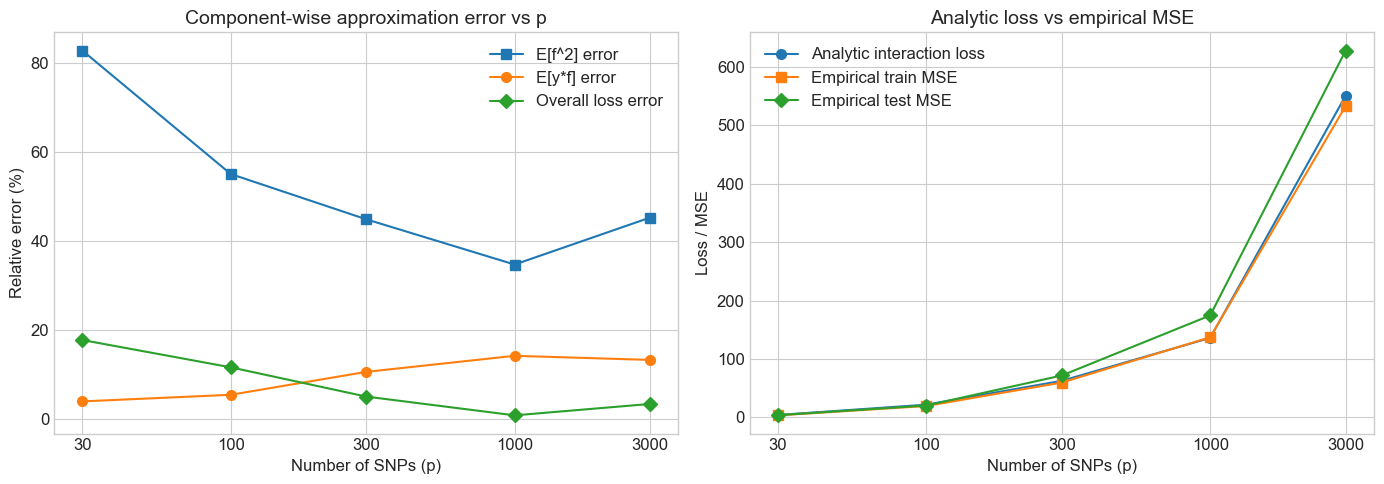

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ps = [r["p"] for r in loss_results]

ax = axes[0]
ax.plot(ps, [r["ef2_err"] * 100 for r in loss_results], 's-', label="E[f^2] error", markersize=7)
ax.plot(ps, [r["eyf_err"] * 100 for r in loss_results], 'o-', label="E[y*f] error", markersize=7)
ax.plot(ps, [r["loss_err"] * 100 for r in loss_results], 'D-', label="Overall loss error", markersize=7)
ax.set_xscale("log")
ax.set_xlabel("Number of SNPs (p)")
ax.set_ylabel("Relative error (%)")
ax.set_title("Component-wise approximation error vs p")
ax.set_xticks(ps)
ax.set_xticklabels([str(p) for p in ps])
ax.legend()

ax = axes[1]
ax.plot(ps, [r["L_analytic"] for r in loss_results], 'o-', label="Analytic interaction loss", markersize=7)
ax.plot(ps, [r["L_train_mse"] for r in loss_results], 's-', label="Empirical train MSE", markersize=7)
ax.plot(ps, [r["L_test_mse"] for r in loss_results], 'D-', label="Empirical test MSE", markersize=7)
ax.set_xscale("log")
ax.set_xlabel("Number of SNPs (p)")
ax.set_ylabel("Loss / MSE")
ax.set_title("Analytic loss vs empirical MSE")
ax.set_xticks(ps)
ax.set_xticklabels([str(p) for p in ps])
ax.legend()

plt.tight_layout()
plt.show()

## Analysis 4: Interaction NN Gap to Oracle vs p

At each p, we train the Gaussian NN, Interaction NN (warm-started), and Oracle NN,
then compare their test R^2. If the Interaction-to-Oracle gap shrinks with p, the
small-p regime was masking the method's true potential. If it persists, there is a
genuine bottleneck beyond the Gaussian approximation issue.

In [8]:
r2_results = []

for p in P_VALUES:
    print(f"p={p:>5d} (n_train={get_n_train(p)}) ...", flush=True)
    data = generate_replicate(p, SEED)
    Sigma = data["Sigma"]
    Sigma_bh = data["Sigma_beta_hat"]
    E_y2 = data["E_y2_hat"]
    Gamma = data["Gamma_hat"]

    gauss = train(
        Sigma, Sigma_bh, E_y2,
        m=M, activation=ACTIVATION, lr=0.01, max_iters=3000,
        init_scale=0.01, rng=np.random.default_rng(100),
    )
    r2_gauss = nn_prediction_r2(data["X_test"], data["y_test"], gauss.a, gauss.W, ACTIVATION)

    int_result = train_interaction(
        Sigma, Sigma_bh, E_y2, Gamma,
        m=M, activation=ACTIVATION, lr=0.005, max_iters=2000,
        rng=np.random.default_rng(200),
        grad_clip=0.5, max_backtracks=10,
        a_init=gauss.a, W_init=gauss.W,
    )
    r2_int = nn_prediction_r2(data["X_test"], data["y_test"], int_result.a, int_result.W, ACTIVATION)

    oracle_iters = max(5000, 2 * p)
    oracle_bs = min(256, data["n_train"] // 4)
    oracle_a, oracle_W, _ = train_oracle_nn(
        data["X_train"], data["y_train"],
        m=M, activation=ACTIVATION, lr=0.01,
        max_iters=oracle_iters, batch_size=oracle_bs,
        rng=np.random.default_rng(300),
    )
    r2_oracle = nn_prediction_r2(data["X_test"], data["y_test"], oracle_a, oracle_W, ACTIVATION)

    r2_results.append({
        "p": p,
        "r2_gauss": r2_gauss,
        "r2_interaction": r2_int,
        "r2_oracle": r2_oracle,
        "gap_int_oracle": r2_oracle - r2_int,
        "gap_frac": (r2_oracle - r2_int) / (r2_oracle + 1e-30),
    })
    print(f"  Gaussian R^2={r2_gauss:.4f}, Interaction R^2={r2_int:.4f}, "
          f"Oracle R^2={r2_oracle:.4f}, gap={r2_oracle - r2_int:.4f}")

print("\n--- Summary ---")
print(f"{'p':>6s} {'Gaussian':>10s} {'Interaction':>12s} {'Oracle':>10s} "
      f"{'Gap':>8s} {'Gap %':>8s}")
print("-" * 58)
for r in r2_results:
    print(f"{r['p']:6d} {r['r2_gauss']:10.4f} {r['r2_interaction']:12.4f} {r['r2_oracle']:10.4f} "
          f"{r['gap_int_oracle']:8.4f} {r['gap_frac']:7.1%}")

p=   30 (n_train=5000) ...


  Gaussian R^2=0.2680, Interaction R^2=0.3288, Oracle R^2=0.5338, gap=0.2050
p=  100 (n_train=5000) ...


  Gaussian R^2=0.2008, Interaction R^2=0.2522, Oracle R^2=0.4078, gap=0.1556
p=  300 (n_train=5000) ...


  Gaussian R^2=0.1958, Interaction R^2=0.2232, Oracle R^2=0.3051, gap=0.0819
p= 1000 (n_train=10000) ...


  Gaussian R^2=0.1884, Interaction R^2=0.2060, Oracle R^2=0.2867, gap=0.0807
p= 3000 (n_train=30000) ...


  Gaussian R^2=0.1983, Interaction R^2=0.2157, Oracle R^2=0.2623, gap=0.0466

--- Summary ---
     p   Gaussian  Interaction     Oracle      Gap    Gap %
----------------------------------------------------------
    30     0.2680       0.3288     0.5338   0.2050   38.4%
   100     0.2008       0.2522     0.4078   0.1556   38.2%
   300     0.1958       0.2232     0.3051   0.0819   26.9%
  1000     0.1884       0.2060     0.2867   0.0807   28.1%
  3000     0.1983       0.2157     0.2623   0.0466   17.8%


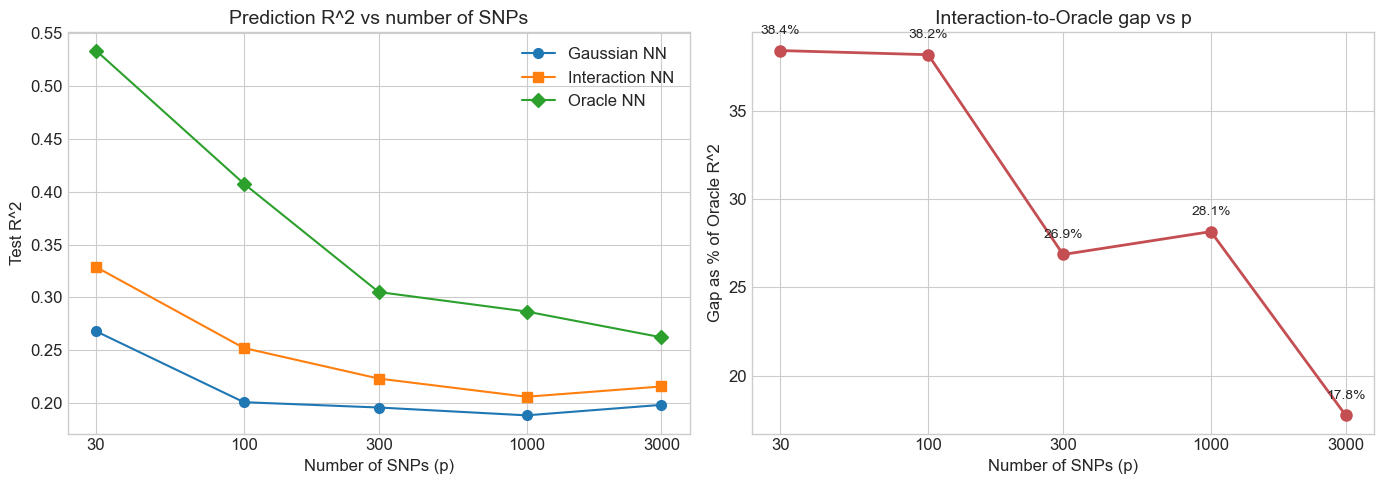

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ps = [r["p"] for r in r2_results]

ax = axes[0]
ax.plot(ps, [r["r2_gauss"] for r in r2_results], 'o-', label="Gaussian NN", markersize=7)
ax.plot(ps, [r["r2_interaction"] for r in r2_results], 's-', label="Interaction NN", markersize=7)
ax.plot(ps, [r["r2_oracle"] for r in r2_results], 'D-', label="Oracle NN", markersize=7)
ax.set_xscale("log")
ax.set_xlabel("Number of SNPs (p)")
ax.set_ylabel("Test R^2")
ax.set_title("Prediction R^2 vs number of SNPs")
ax.set_xticks(ps)
ax.set_xticklabels([str(p) for p in ps])
ax.legend()

ax = axes[1]
ax.plot(ps, [r["gap_frac"] * 100 for r in r2_results], 'o-', markersize=8, linewidth=2,
        color="#c44e52")
ax.set_xscale("log")
ax.set_xlabel("Number of SNPs (p)")
ax.set_ylabel("Gap as % of Oracle R^2")
ax.set_title("Interaction-to-Oracle gap vs p")
ax.set_xticks(ps)
ax.set_xticklabels([str(p) for p in ps])
for p_val, r in zip(ps, r2_results):
    ax.annotate(f"{r['gap_frac']*100:.1f}%", (p_val, r['gap_frac']*100),
                textcoords="offset points", xytext=(0, 12), ha="center", fontsize=10)

plt.tight_layout()
plt.show()

## Variance Estimates: 5 Replicates at p=30 and p=1000

To ensure the single-replicate results above are not flukes, we run 5 replicates
at the two ends of the spectrum (p=30 and p=1000) and report means and standard errors.

In [10]:
N_REPS = 5
VARIANCE_PS = [30, 1000]

for p in VARIANCE_PS:
    print(f"\n{'='*60}")
    print(f"Variance check: p={p}, {N_REPS} replicates")
    print(f"{'='*60}")

    rep_ef2_errs = []
    rep_r2_gauss = []
    rep_r2_int = []
    rep_r2_oracle = []

    for rep in range(N_REPS):
        seed_rep = 1000 + rep * 100
        data = generate_replicate(p, seed_rep)
        Sigma = data["Sigma"]
        Sigma_bh = data["Sigma_beta_hat"]
        E_y2 = data["E_y2_hat"]
        Gamma = data["Gamma_hat"]

        gauss = train(
            Sigma, Sigma_bh, E_y2,
            m=M, activation=ACTIVATION, lr=0.01, max_iters=3000,
            init_scale=0.01, rng=np.random.default_rng(100 + rep),
        )

        ef2_a = sum(
            gauss.a[k] * gauss.a[l] * activation_cross_moment(Sigma, gauss.W[k], gauss.W[l], ACTIVATION)
            for k in range(M) for l in range(M)
        )
        f_tr = nn_predict(data["X_train"], gauss.a, gauss.W, ACTIVATION)
        ef2_e = float(np.mean(f_tr ** 2))
        rep_ef2_errs.append(abs(ef2_a - ef2_e) / (abs(ef2_e) + 1e-30))

        r2_g = nn_prediction_r2(data["X_test"], data["y_test"], gauss.a, gauss.W, ACTIVATION)
        rep_r2_gauss.append(r2_g)

        int_res = train_interaction(
            Sigma, Sigma_bh, E_y2, Gamma,
            m=M, activation=ACTIVATION, lr=0.005, max_iters=2000,
            rng=np.random.default_rng(200 + rep),
            grad_clip=0.5, max_backtracks=10,
            a_init=gauss.a, W_init=gauss.W,
        )
        r2_i = nn_prediction_r2(data["X_test"], data["y_test"], int_res.a, int_res.W, ACTIVATION)
        rep_r2_int.append(r2_i)

        oracle_iters = max(5000, 2 * p)
        oracle_bs = min(256, data["n_train"] // 4)
        o_a, o_W, _ = train_oracle_nn(
            data["X_train"], data["y_train"],
            m=M, activation=ACTIVATION, lr=0.01,
            max_iters=oracle_iters, batch_size=oracle_bs,
            rng=np.random.default_rng(300 + rep),
        )
        r2_o = nn_prediction_r2(data["X_test"], data["y_test"], o_a, o_W, ACTIVATION)
        rep_r2_oracle.append(r2_o)

        print(f"  Rep {rep}: E[f^2] err={rep_ef2_errs[-1]:.1%}, "
              f"R^2 gauss={r2_g:.4f}, int={r2_i:.4f}, oracle={r2_o:.4f}")

    se = lambda x: np.std(x) / np.sqrt(len(x))
    print(f"\n  E[f^2] error:     {np.mean(rep_ef2_errs):.1%} +/- {se(rep_ef2_errs):.1%}")
    print(f"  R^2 Gaussian:     {np.mean(rep_r2_gauss):.4f} +/- {se(rep_r2_gauss):.4f}")
    print(f"  R^2 Interaction:  {np.mean(rep_r2_int):.4f} +/- {se(rep_r2_int):.4f}")
    print(f"  R^2 Oracle:       {np.mean(rep_r2_oracle):.4f} +/- {se(rep_r2_oracle):.4f}")
    gaps = np.array(rep_r2_oracle) - np.array(rep_r2_int)
    print(f"  Int-Oracle gap:   {np.mean(gaps):.4f} +/- {se(gaps):.4f}")


Variance check: p=30, 5 replicates


  Rep 0: E[f^2] err=128.0%, R^2 gauss=0.2485, int=0.3111, oracle=0.5231


  Rep 1: E[f^2] err=147.9%, R^2 gauss=-0.0236, int=-0.0251, oracle=0.4926


  Rep 2: E[f^2] err=122.3%, R^2 gauss=0.2270, int=0.2933, oracle=0.3860


  Rep 3: E[f^2] err=87.7%, R^2 gauss=0.0819, int=0.1663, oracle=0.2733


...

  Rep 0: E[f^2] err=69.1%, R^2 gauss=0.1653, int=0.1967, oracle=0.2280


  Rep 1: E[f^2] err=71.0%, R^2 gauss=0.1970, int=0.2052, oracle=0.2695


  Rep 2: E[f^2] err=72.1%, R^2 gauss=0.1823, int=0.1840, oracle=0.2476


  Rep 3: E[f^2] err=82.4%, R^2 gauss=0.1925, int=0.2000, oracle=0.2273


  Rep 4: E[f^2] err=80.3%, R^2 gauss=0.2035, int=0.1981, oracle=0.2740

  E[f^2] error:     75.0% +/- 2.4%
  R^2 Gaussian:     0.1881 +/- 0.0060
  R^2 Interaction:  0.1968 +/- 0.0031
  R^2 Oracle:       0.2493 +/- 0.0089
  Int-Oracle gap:   0.0525 +/- 0.0087


## Conclusions

Interpret the results above:

- **If E[f^2] error drops from ~80-100% at p=30 to <10% at p=1000+**: the CLT hypothesis
  is confirmed. The Gaussian assumption is sound for genome-scale applications, and the
  `interaction_diagnostics` findings were a small-p artifact.

- **If the error remains large even at p=3000**: the Gaussian assumption is a fundamental
  limitation, not just a finite-p issue. The `E[f^2]` formula would need non-Gaussian
  corrections (analogous to what the Edgeworth expansion does for `E[y*f]`).

- **If the Interaction-to-Oracle gap shrinks with p**: the method's potential was masked
  by the small-p regime, and genome-scale tests are warranted.

- **If the gap persists**: there is a genuine information or optimization bottleneck in
  the Interaction NN that is independent of the Gaussian approximation quality.